In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

In [4]:
ip_data = pd.read_csv('Data/INDPRO.csv')

In [5]:
ip_data.head()

,observation_date,INDPRO
0,1919-01-01,4.8739
1,1919-02-01,4.6585
2,1919-03-01,4.5238
3,1919-04-01,4.6046
4,1919-05-01,4.6315


In [6]:
ip_data = ip_data.rename(columns = {'INDPRO': 'IP'})
print(ip_data.head())

  observation_date      IP
0       1919-01-01  4.8739
1       1919-02-01  4.6585
2       1919-03-01  4.5238
3       1919-04-01  4.6046
4       1919-05-01  4.6315


In [7]:
ip_data['IP_log'] = np.log(ip_data['IP'])
ip_data['IP_log_12diff'] = ip_data['IP_log'] - ip_data['IP_log'].shift(12)

In [8]:
ip_data.head(20)

,observation_date,IP,IP_log,IP_log_12diff
0,1919-01-01,4.8739,1.583894,NaN
1,1919-02-01,4.6585,1.538694,NaN
2,1919-03-01,4.5238,1.509352,NaN
3,1919-04-01,4.6046,1.527056,NaN
4,1919-05-01,4.6315,1.532881,NaN
5,1919-06-01,4.9277,1.594872,NaN
6,1919-07-01,5.2239,1.653244,NaN
7,1919-08-01,5.3047,1.668593,NaN
8,1919-09-01,5.1970,1.648082,NaN
9,1919-10-01,5.1432,1.637675,NaN


In [9]:
#keep dates after 1982-01-01
ip_data = ip_data[ip_data['observation_date'] >= '1982-01-01']
ip_data['observation_date'] = pd.to_datetime(ip_data['observation_date'])

In [10]:
t10y3m_data = pd.read_csv('C:\\Users\\aweso\\OneDrive - Clark University\\Year 4 Semester 2\\ECON 266 - Economic Forecasting\\Final Project\\T10Y3M.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\aweso\\OneDrive - Clark University\\Year 4 Semester 2\\ECON 266 - Economic Forecasting\\Final Project\\T10Y3M.csv'

In [ ]:
t10y3m_data.head()

,observation_date,T10Y3M
0,1982-01-04,2.32
1,1982-01-05,2.24
2,1982-01-06,2.43
3,1982-01-07,2.46
4,1982-01-08,2.50


In [ ]:
t10y3m_data.dropna(inplace=True)

In [ ]:
#keep only the first of the month
t10y3m_data['observation_date'] = pd.to_datetime(t10y3m_data['observation_date'])
t10y3m_data = t10y3m_data[t10y3m_data['observation_date'].dt.day == 1]

In [ ]:
t10y3m_data.head()

,observation_date,T10Y3M
20,1982-02-01,-0.19
40,1982-03-01,1.04
63,1982-04-01,0.23
106,1982-06-01,1.38
128,1982-07-01,1.26


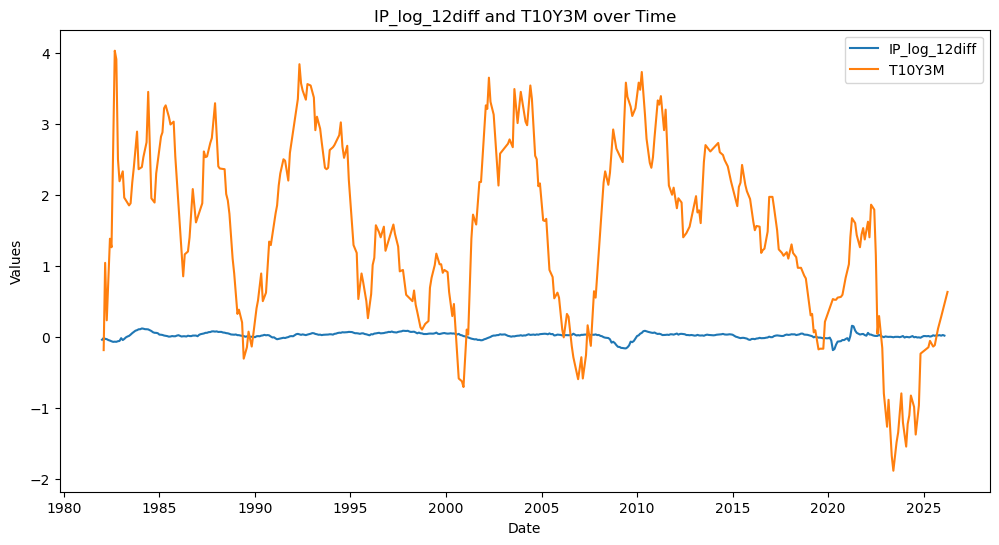

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(ip_data['observation_date'], ip_data['IP_log_12diff'], label='IP_log_12diff')
plt.plot(t10y3m_data['observation_date'], t10y3m_data['T10Y3M'], label='T10Y3M')
plt.xlabel('Date')
plt.ylabel('Values')
plt.title('IP_log_12diff and T10Y3M over Time')
plt.legend()
plt.show()

### ARIMA MODDEL

#### Plotting ACF and PACF Plots

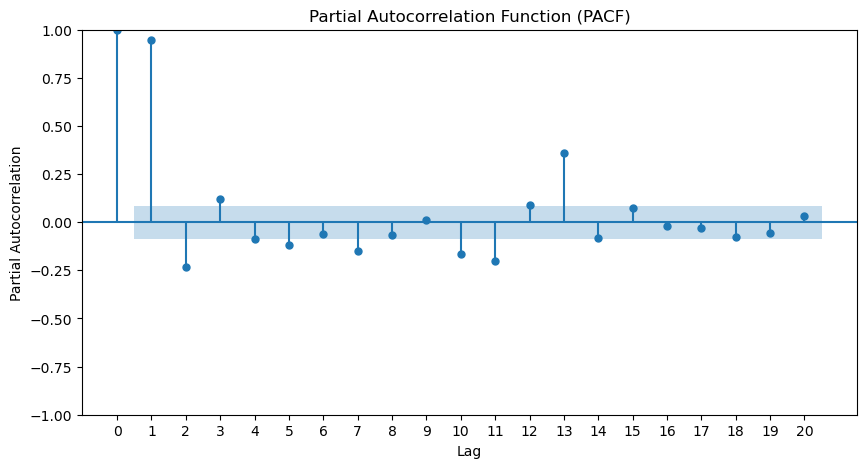

In [ ]:
#Plot PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(ip_data['IP_log_12diff'], lags=20, ax=ax, method='ywm') # Plot first 20 lags
ax.set_xlabel("Lag")
ax.set_xticks(range(0, 21, 1))
ax.set_ylabel("Partial Autocorrelation")
ax.set_title("Partial Autocorrelation Function (PACF)")
plt.show() 

We see here that the last lag that goes outside the confidence interval is lag 13

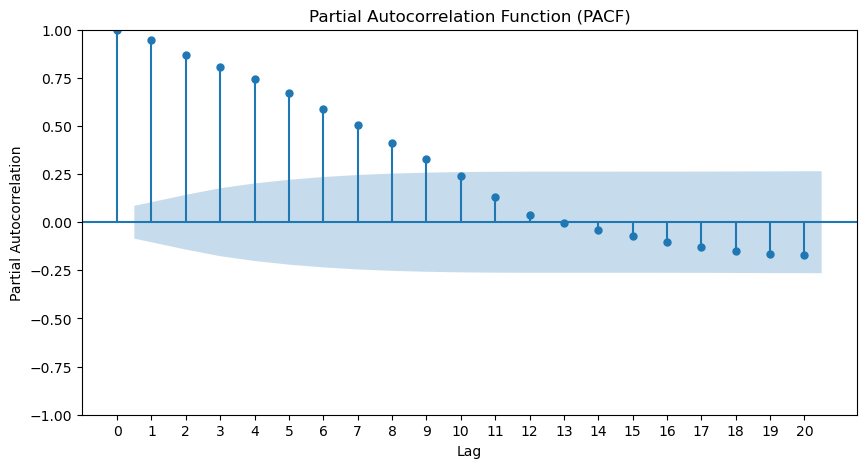

In [57]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(ip_data['IP_log_12diff'], lags=20, ax=ax) # Plot first 20 lags
ax.set_xlabel("Lag")
ax.set_xticks(range(0, 21, 1))
ax.set_ylabel("Partial Autocorrelation")
ax.set_title("Partial Autocorrelation Function (PACF)")
plt.show() 

We see here that the last lag that goes outside the confidence interval is lag 9